# Forecasting Urban Power Consumption with Machine Learning


## Project Overview
This project analyzes how weather conditions affect electricity consumption across three urban zones in Tetuan City, Morocco. Using temperature, humidity, and wind speed as input features, I built regression models to predict zone-level power consumption and evaluate how well simple linear methods explain demand patterns.

## Objectives
- Explore relationships between weather variables and power consumption
- Compare predictive performance across three zones
- Evaluate the strengths and limitations of linear regression
- Use residual analysis to better understand model behavior

## Background and Motivation


1. Medium Article: Predicting Electricity Consumption Using Weather Data
   
This article shows a project that uses multivariate time series analysis and the vector auto regression (VAR) model to predict electricity consumption in New York City. This analysis shows a strong relationship between weather variables temperature and humidy alongside electricity usage. Some main points include:

Increased electricity demanded when there was extreme weather due to air conditioning in hot weather and heating in cold weather.

Shows the importance of correct and acccurate forecasting for energy demand to make sure grid stability and efficiency is opperating at its finest. Especially when communities adopt more renewable energy sources. These articles shows a practical example of using machine learning to optimize Energy management systems.

- **Key Insight**: Temperature and humidity significantly influence electricity consumption patterns, with extreme temperatures (hot or cold) increasing demand due to heating or cooling needs.
- **Relevance**: Aligns with using temperature and humidity as input features for modeling power consumption.


2. Research Paper: A Study of the Relationship between Weather Variables and Electric Power Demand inside a Smart Grid/Smart World Framework

This one focuses on the understandment of how eather variables (temperature, humidity, and wind speed specifically) impact electric power demand within the context of smart grids. 

Smart grids do rely on predictive models that incorporate weather data in order to manage energy distribution in an efficient way.

This study shows patterns of energy demand alongside different weather conditions, showing insights for real time decision making.

The findings goal is to improve the responsiveness of smart grids, making sure reliability and performance in varying weather scenarios is still as best as possible. The research shows the importance of mixing weather forecasting with grid operation in order to optimize electricity consumption.

**Key Insight**: A combination of weather variables (temperature, humidity, wind speed) and user behavior affect power demand. Smart grids can improve efficiency by leveraging weather predictions.
- **Relevance**: Highlights the importance of wind speed in predicting power consumption and supports the inclusion of all 

3. NREL Report: Predicting the Response of Electricity Load to Climate Change

   This report gives a framework for showing logistically how climate change affefcts electricity demand. Using linear regression model, it analyzes the relationship between temperature and energy load in different U.S. transmission zones.

   It identifies the load sensitivities with heating and colloing requirements as temperatures change.

    Its methodology to pair historical weather and load data to better predict future impacts under certain climate change scenarios.

   It has appliocations in long term planning in order to better adapt energy systems for betterment in extreme weather events. The report gives valuable tools for potential policymakers, utility companies, and curious people to prepare for climate related challenges in energy demand.

 - **Key Insight**: Renewable energy production and power consumption are influenced by seasonal weather patterns, requiring accurate modeling for grid stability.
- **Relevance**: Supports analyzing time-based trends and seasonal effects on power consumption.


In [1]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Exploratory Data Analysis

I examined the dataset structure, checked for missing values, and visualized the main variables using histograms, pair plots, and time-based trend charts.

### Key observations
- Temperature is centered around a moderate range, with many values near 18°C.
- Humidity is concentrated at relatively high levels, with many observations near 70%.
- Wind speed is heavily right-skewed, with most values close to zero.
- Temperature shows a modest positive relationship with power consumption.
- Humidity and wind speed appear to have weaker or less consistent relationships with the target variables.
- Power consumption changes over both seasonal and hourly time scales, suggesting that time-related features could improve future models.

In [2]:
df = pd.read_csv("Tetuan City power consumption.csv")
# Loading the dataset and assign clearer column names
df.columns = [
    "DateTime",
    "Temperature",
    "Humidity",
    "WindSpeed",
    "Zone1Power",
    "Zone2Power",
    "Zone3Power"
]
# Converting # Convert the timestamp so we can actually work with time-based patterns
df["DateTime"] = pd.to_datetime(df["DateTime"], format="%m/%d/%y %H:%M")

# Make sure numeric columns are actually numeric (invalids get turned into NaN)
numeric_cols = ["Temperature", "Humidity", "WindSpeed", "Zone1Power", "Zone2Power", "Zone3Power"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

#Drop the NaN and Visualize the data
df = df.dropna()
print("Shape:", df.shape)
print("\nMissing values by column:")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)

summary_statistics = df.describe()
summary_statistics

Shape: (52416, 7)

Missing values by column:
DateTime       0
Temperature    0
Humidity       0
WindSpeed      0
Zone1Power     0
Zone2Power     0
Zone3Power     0
dtype: int64

Data types:
DateTime       datetime64[us]
Temperature           float64
Humidity              float64
WindSpeed             float64
Zone1Power            float64
Zone2Power            float64
Zone3Power            float64
dtype: object


,DateTime,Temperature,Humidity,WindSpeed,Zone1Power,Zone2Power,Zone3Power
count,52416,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,2017-07-01 23:55:00,18.810024,68.259518,1.959489,32344.970564,21042.509082,17835.406218
min,2017-01-01 00:00:00,3.247000,11.340000,0.050000,13895.696200,8560.081466,5935.174070
25%,2017-04-01 23:57:30,14.410000,58.310000,0.078000,26310.668692,16980.766032,13129.326630
50%,2017-07-01 23:55:00,18.780000,69.860000,0.086000,32265.920340,20823.168405,16415.117470
75%,2017-09-30 23:52:30,22.890000,81.400000,4.915000,37309.018185,24713.717520,21624.100420
max,2017-12-30 23:50:00,40.010000,94.800000,6.483000,52204.395120,37408.860760,47598.326360
std,NaN,5.815476,15.551177,2.348862,7130.562564,5201.465892,6622.165099


## Dataset Overview

The dataset contains 52,416 valid observations from 2017, with measurements recorded at regular time intervals. It includes one timestamp column, three weather-related input variables, and three target variables representing power consumption in separate urban zones.

### Variables
- **DateTime**: Timestamp of each observation
- **Temperature**: Air temperature in degrees Celsius
- **Humidity**: Relative humidity as a percentage
- **WindSpeed**: Wind speed in meters per second
- **Zone1Power**: Power consumption in Zone 1
- **Zone2Power**: Power consumption in Zone 2
- **Zone3Power**: Power consumption in Zone 3

After loading the data, I found that the file contained a large number of empty rows. These rows were removed during preprocessing using dropna(), resulting in a clean dataset with no missing values in the final analysis.

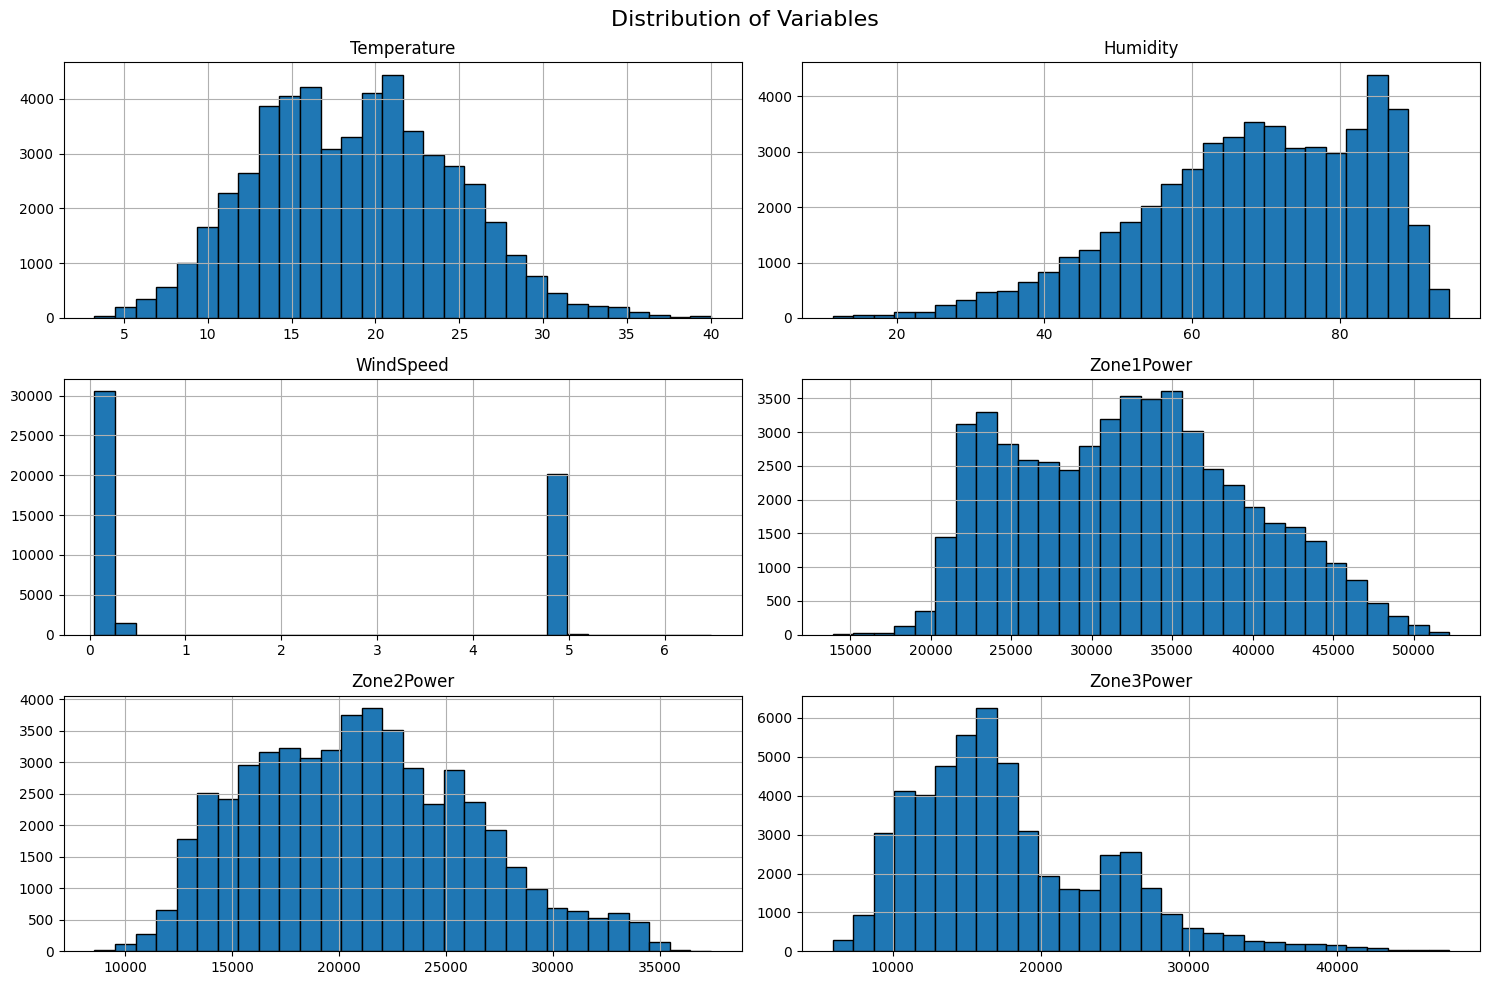

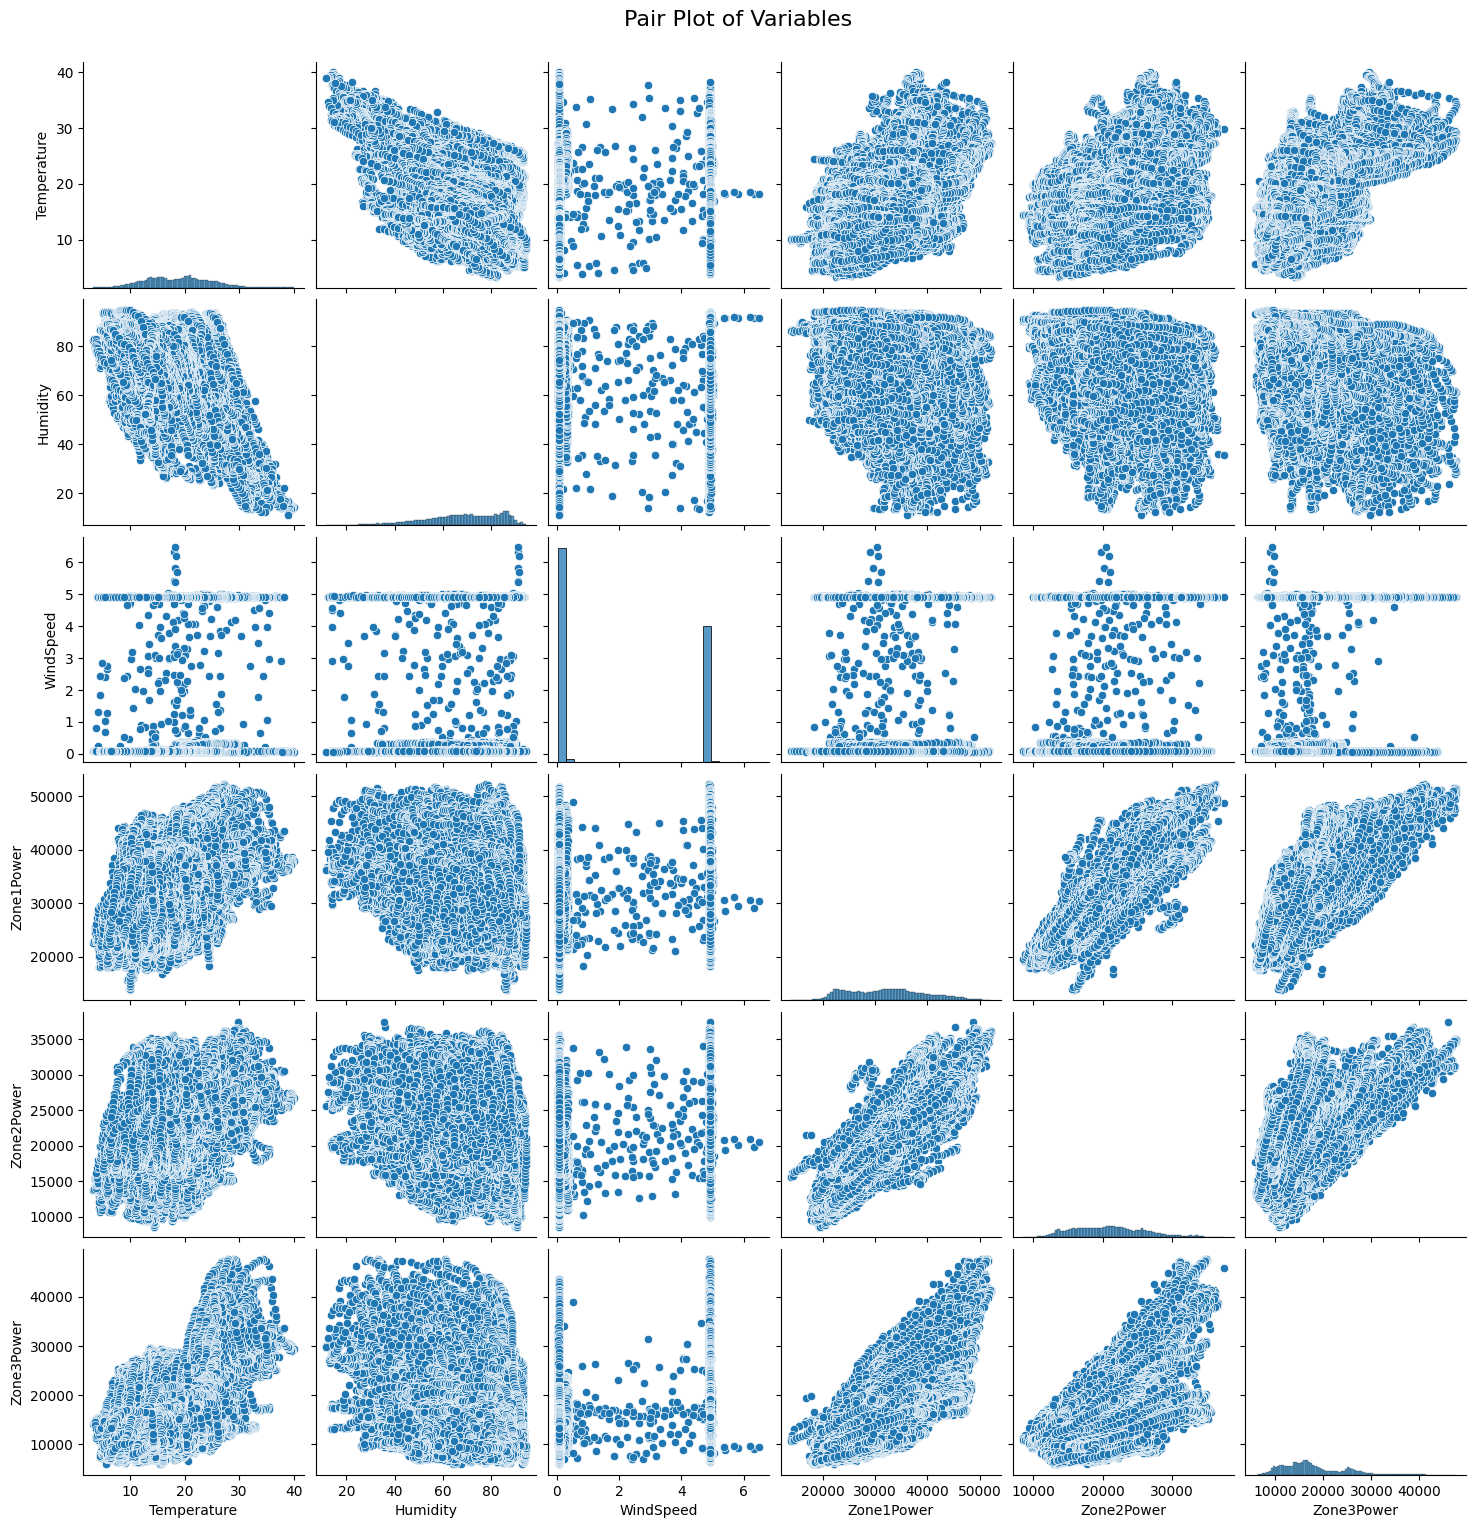

In [3]:

# Look at how each variable is distributed (Helps us spots skew, clustering, or anything unusual)
df[['Temperature', 'Humidity', 'WindSpeed', 'Zone1Power', 'Zone2Power', 'Zone3Power']].hist(
figsize=(15, 10), bins=30, edgecolor='black')
plt.suptitle("Distribution of Variables", fontsize=16)
plt.tight_layout()
plt.show()

#Pair Plot to get a quick view of how variables relate to eachother (Good for trends and Correlations)
sns.pairplot(df[['Temperature', 'Humidity', 'WindSpeed', 'Zone1Power', 'Zone2Power', 'Zone3Power']])
plt.suptitle("Pair Plot of Variables", fontsize=16, y=1.02) # were using y here so the title has better readability
plt.show()

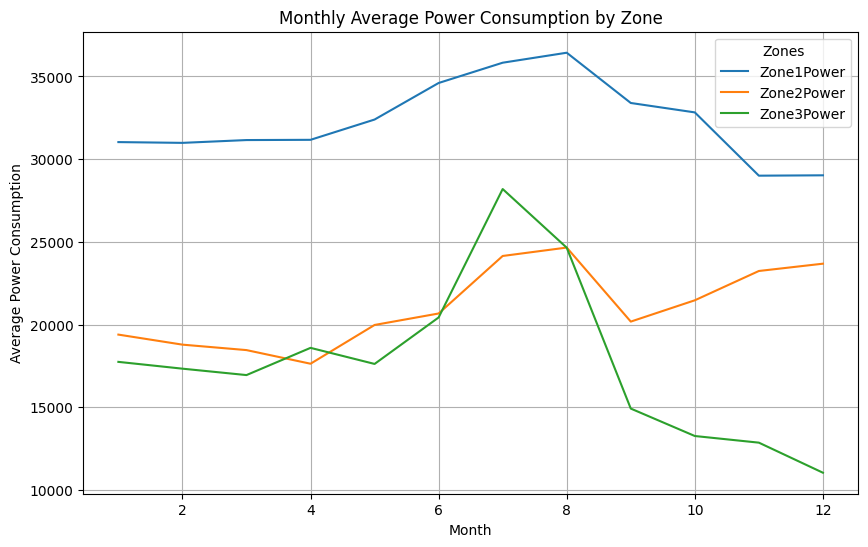

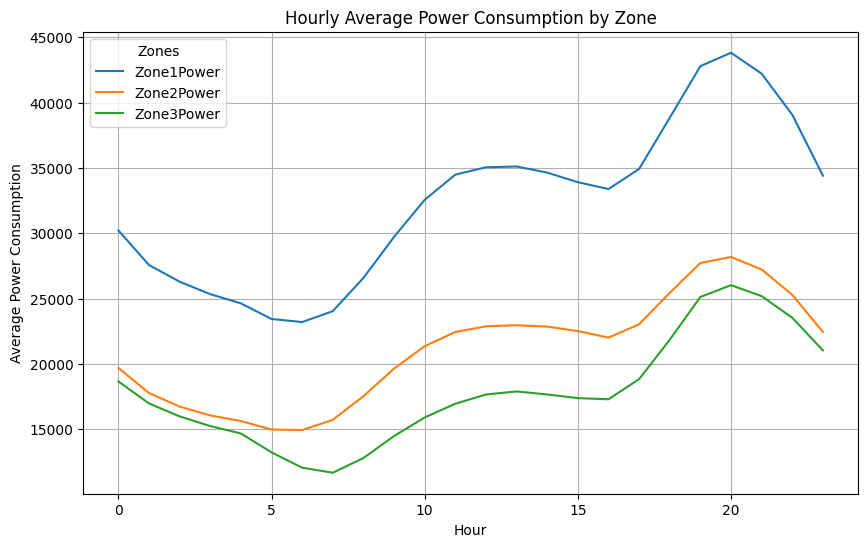

In [4]:
# Analyzing trend over time by pulling out year, month, and hour from the time stamps
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Hour'] = df['DateTime'].dt.hour

# Checking how power usage changes seasonally (month to month)
monthly_trends = df.groupby('Month')[['Zone1Power', 'Zone2Power', 'Zone3Power']].mean()

monthly_trends.plot(figsize=(10, 6))
plt.title("Monthly Average Power Consumption by Zone")
plt.xlabel("Month")
plt.ylabel("Average Power Consumption")
plt.legend(title="Zones")
plt.grid()
plt.show()

# Checking daily power usage changes
hourly_trends = df.groupby('Hour')[['Zone1Power', 'Zone2Power', 'Zone3Power']].mean()

hourly_trends.plot(figsize=(10, 6))
plt.title("Hourly Average Power Consumption by Zone")
plt.xlabel("Hour")
plt.ylabel("Average Power Consumption")
plt.legend(title="Zones")
plt.grid()
plt.show()

## Model Building

### Zone 1: Linear Regression from Scratch (Below)
- **Process**:
  1. Implement my own linear regression using Python.
  - Here we have 41,932 samples for training, 10,484 for testing, all features are normalized so we can have a consitent scaling within the model training
  2. Train and test the model with normalized data.
  3. Evaluate using ( R^2) and RMSE metrics.
- **Results**:
  - The Training ( R^2) ended up being 0.0327 (poor fit), Testing (R^2) was 0.0265 (poor fit probably because of the limited linear relationships).
  - The training RMSE was 7018.84, The testing RMSE was 7011. This linear regression model from scratch shows very poor predicting power which means to analyze these zones, we must use more complex models.
  - This shows a need for more complex/flexible models as my from scratch model will give not as good results as the already defined library models if the data isnt linear.




In [5]:
#Selecting weather features as inputs and zone power as targets
features = df[['Temperature', 'Humidity', 'WindSpeed']]
targets = {
    "Zone1Power": df["Zone1Power"],
    "Zone2Power": df["Zone2Power"],
    "Zone3Power": df["Zone3Power"],
}

# Normalizing the features for scallability purposes
scaler = MinMaxScaler()
features_normalized = scaler.fit_transform(features)

# Splitting the data into training and testing sets for each zone (20% testing and 80% training)
splits = {}
for zone, target in targets.items():
    splits[zone] = train_test_split(features_normalized, target, test_size=0.2, random_state=42)


# Checking split sizes (Should be ~80/20)
splits_structure = {}
for zone in splits.keys():
    shapes = []
    for data in splits[zone]:
        shapes.append(data.shape)
    splits_structure[zone] = shapes
splits_structure


{'Zone1Power': [(41932, 3), (10484, 3), (41932,), (10484,)],
 'Zone2Power': [(41932, 3), (10484, 3), (41932,), (10484,)],
 'Zone3Power': [(41932, 3), (10484, 3), (41932,), (10484,)]}

In [6]:
import numpy as np
#Scratch model
# Building a simple linear regression model from scratch for Zone 1 for self understanding of algorithms
X_train, X_test, y_train, y_test = splits["Zone1Power"]


class LinearRegressionFromScratch:
    def __init__(self): 
                        
        self.weights = None 
        self.bias = None

    # Initializing weights and bias
    def fit(self, X, y, epochs=1000, learning_rate=0.01):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Used Gradient Descent to minimize prediction error
        for _ in range(epochs):
            y_predicted = np.dot(X, self.weights) + self.bias
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)
            self.weights -= learning_rate * dw
            self.bias -= learning_rate * db

    # Predictions based off the trained model
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


# Training the model on the training data
zone1_model = LinearRegressionFromScratch()
zone1_model.fit(X_train, y_train)

# Evaluating the performance (both training and testing)
y_pred_train = zone1_model.predict(X_train)
y_pred_test = zone1_model.predict(X_test)

#Calculating R^2 and RMSE to measure fit and prediction error
def r2_score(y_true, y_pred):
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_residual = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_residual / ss_total)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

zone1_r2_train = r2_score(y_train, y_pred_train)
zone1_r2_test = r2_score(y_test, y_pred_test)
zone1_rmse_train = rmse(y_train, y_pred_train)
zone1_rmse_test = rmse(y_test, y_pred_test)

zone1_r2_train, zone1_r2_test, zone1_rmse_train, zone1_rmse_test


(np.float64(0.03272007385508213),
 np.float64(0.02654242703332821),
 np.float64(7018.836505317641),
 np.float64(7011.00155747467))

### Zones 2 & 3: Scikit-Learn Models

- **Process (Similar as before)**:
  1. Use linear regression with Scikit-learn for Zones 2 and 3.
     -Zone 2: 41,932 samples for training, 10,484 for testing. Zone 3: 41,932 samples for training, 10,484 for testing. 
  2. Evaluated models using (R^2) and RMSE.
  3. Compared performance.
- **Results**:
  -From these models I found:
  - Zone 2:
      - Training 𝑅^2: 0.1634 (Better predictions than Zone 1 but still low)
      - Testing 𝑅^2: 0.1708 (Better predictions than Zone 1 but still low)
      - Training RMSE: 4758.87 (Least Prediction Errors)
      - Testing RMSE: 4730.78 (Least Prediction Errors)

  - Zone 3:
       - Training 𝑅^2: 0.2415 (Best predictions)
       - Testing 𝑅^2: 0.2461 (Best predictions)
       - Training RMSE: 5771.20 (Middle of the models for Prediction Errors)
       - Testing RMSE: 5733.54 (Middle of the models for Prediction Errors)

In [7]:
#Helper function to train and evaluate a sklearn linear regression model
def train_evaluate_model(X_train, X_test, y_train, y_test):
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    return model, r2_train, r2_test, rmse_train, rmse_test

#Training and Evaluating Zone 2
zone2_model, zone2_r2_train, zone2_r2_test, zone2_rmse_train, zone2_rmse_test = train_evaluate_model(*splits["Zone2Power"])

# Training and Evaluating Zone 3
zone3_model, zone3_r2_train, zone3_r2_test, zone3_rmse_train, zone3_rmse_test = train_evaluate_model(*splits["Zone3Power"])

# Storing Results
zone2_results = (f'Zone2:\nTraining R^2: {zone2_r2_train}\nTesting R^2: {zone2_r2_test}\nTraining RMSE: {zone2_rmse_train}\nTesting RMSE: {zone2_rmse_test}')
zone3_results = (f'Zone3:\nTraining R^2: {zone3_r2_train}\nTesting R^2: {zone3_r2_test}\nTraining RMSE: {zone3_rmse_train}\nTesting RMSE: {zone3_rmse_test}')

print(zone2_results,'\n\n',zone3_results) 


Zone2:
Training R^2: 0.16341737763878328
Testing R^2: 0.17078305579449182
Training RMSE: 4758.8655761959535
Testing RMSE: 4730.777946821973 

 Zone3:
Training R^2: 0.2415280087866989
Testing R^2: 0.24610037012427022
Training RMSE: 5771.200232754119
Testing RMSE: 5733.53592117386


## Prediction Function

I created a prediction function that takes temperature, humidity, and wind speed as inputs and returns estimated power consumption for each zone using the trained models.

### Test scenarios
To verify that the function behaved as expected, I tested it using three predefined weather conditions.

### Observations
- Zone 1 consistently returned the highest predicted consumption values.
- Zone 2 generally fell between the other two zones.
- Zone 3 consistently returned the lowest predicted consumption values.

These results suggest that each zone follows a distinct demand pattern under the same environmental conditions.

In [8]:

def predict_power_consumption(temp, humidity, wind_speed, models, scaler):
    # Scaling
    input_features = scaler.transform([[temp, humidity, wind_speed]])
    predictions = {}
    for zone, model in models.items():
        predictions[zone] = model.predict(input_features)[0]
    
    return predictions

# Predefined conditions
test_conditions = [
    (12.5, 71.0, 0.073),
    (21.8, 85.2, 0.068),
    (17.9, 54.0, 0.083),
]

#My models
models = {
    "Zone1Power": zone1_model,
    "Zone2Power": zone2_model,
    "Zone3Power": zone3_model,
}

# Running predictions using the trained models
predictions = []
for temp, hum, wind in test_conditions:
    prediction = predict_power_consumption(temp, hum, wind, models, scaler)
    predictions.append(prediction)

predictions


c:\Users\jayde\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\jayde\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\jayde\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


[{'Zone1Power': np.float64(29485.14786094577),
  'Zone2Power': np.float64(19156.00685944493),
  'Zone3Power': np.float64(14205.339388380207)},
 {'Zone1Power': np.float64(33831.792233060405),
  'Zone2Power': np.float64(21183.72358536745),
  'Zone3Power': np.float64(18957.332734508043)},
 {'Zone1Power': np.float64(29454.293538274906),
  'Zone2Power': np.float64(21572.94698773042),
  'Zone3Power': np.float64(17102.307168762367)}]

### Visualizing the Data


To better evaluate model performance, I visualized the residuals using both scatter plots and histograms. This provides insight into prediction bias, error distribution, and overall model reliability beyond numerical metrics alone.


### Results:
Across all three models, the residual distributions show a tendency toward positive residual values, indicating that the models generally underestimate power consumption.
- Zone 1:
    1. Scatter Plot:
        - The residuals are spread widely
        - The spread is uneven with the model shows a bias toward underestimation
  
    2. Histogram:
        - The mean for the residual is 244.7, which is very high compared to the other zones which shows its strong bias
        - The range is also the largest, from -13,769 to 14258 which we knew would happen from its high error variability
        - The large mean and wide range confirm that the model has high variability and poor predictive performance

    Overall, this reinforces that the from-scratch linear regression model is too simple and fails to capture the underlying patterns in Zone 1.


- Zone 2:
    1. Scatter Plot:
        - Residuals are more tightly clustered around the ideal line (y = 0)
        - There are less outliers in the data showing that this model is more stable
      
    2. Histogram:
       - The mean for the residuals is 51.46 which is the closest to zero out of all three zones showing low bias
       - The range of the residuals is the smallest with it being -9,409 to 9,512 showing low error variability
       - The narrow range and low mean show that this model has lower prediction errors and improved consistency
    
This aligns with the model’s lower RMSE, confirming that Zone 2 provides the most accurate predictions overall.

- Zone 3:
    1. Scatter Plot:
       - Residuals are spread out especially at the higher levels of actual power consumption
       - Predictions appear more accurate at lower consumption levels

    2. Histogram:
       - The mean for the residuals is 86.39 which is the middle ground between the zones
       - The range follows this middle ground between the zones trend with it being from -11,379 to 11,552
       - This indicates moderate bias and variability

While this model does not minimize prediction error as effectively as Zone 2, it achieves the highest R² value, suggesting it captures overall trends more effectively
      
### Overall:

- Zone 1:
  - This model is further proved to be poorly calibrated with its high residual variability and a large bias (the mean of the residuals). It struggles to generalize the data and has the weakest performance
 
- Zone 2:
  - This model is still the best for prediction accuracy out of the others, with its small range and smallest variability.

- Zone 3:
  - This model is good at capturing the overall trends. This is due to it having the highest R^2 but at the same time more variability in its residuals. This balance between accuracy and variability is what makes it the best out of the models at understanding trends and relationships.
         


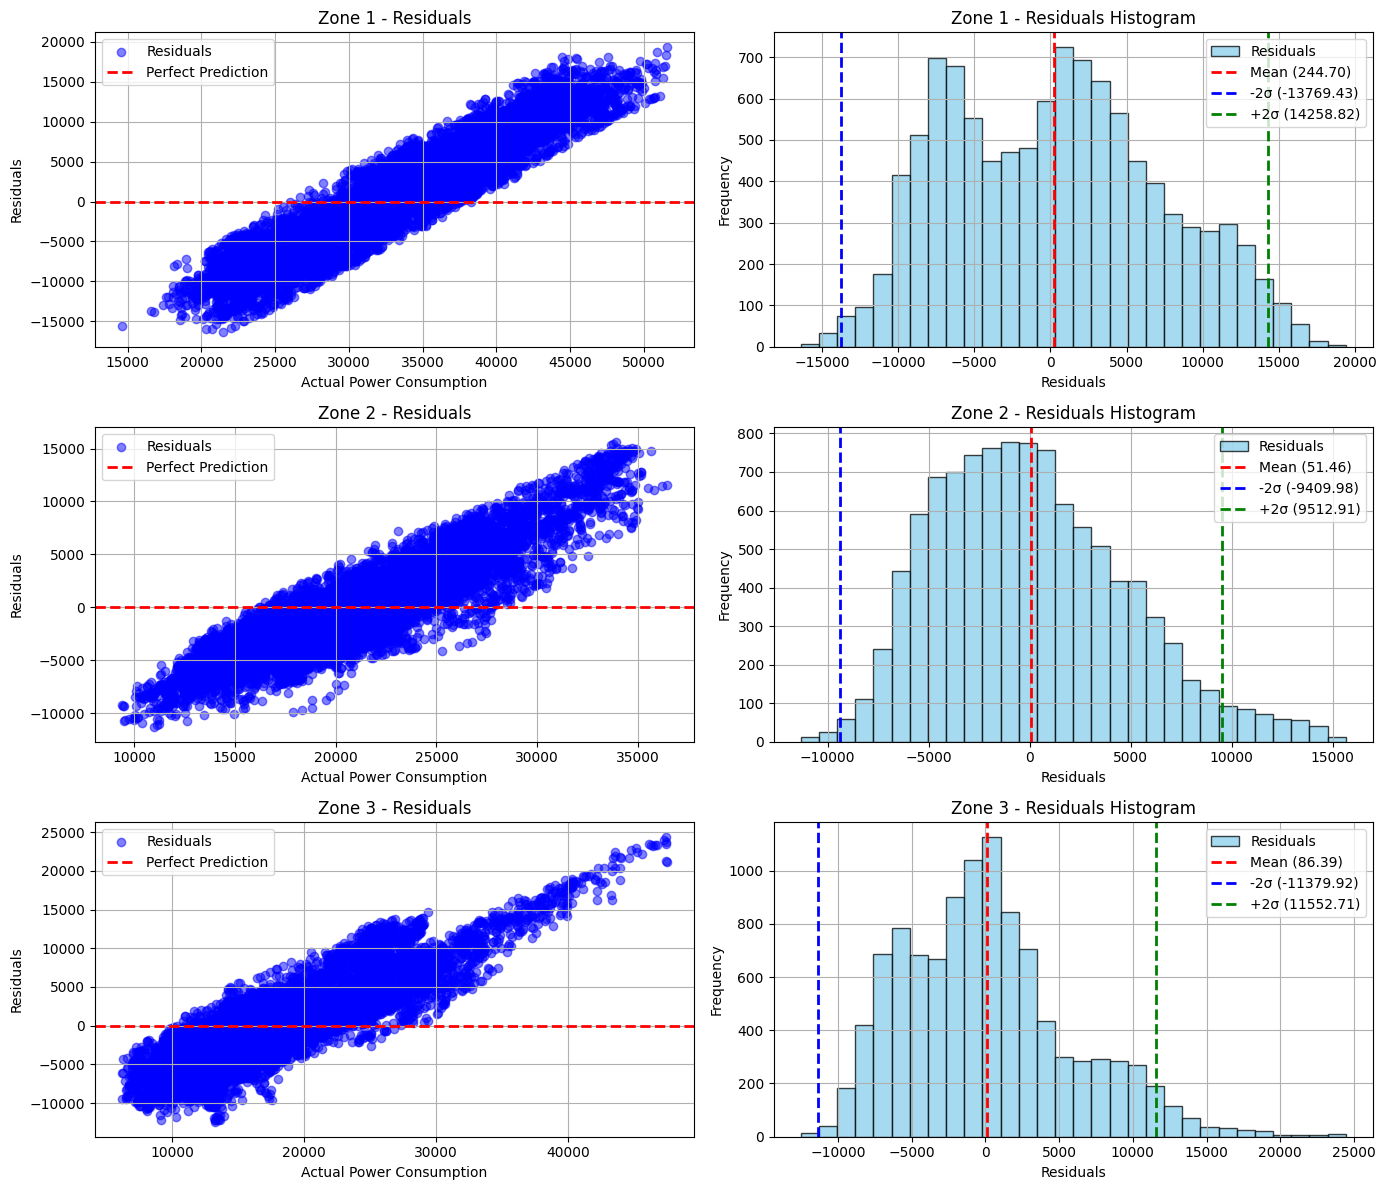

In [9]:
# Comparing model performances using actual vs predicted values
zone1_actual_vs_predicted = pd.DataFrame({
    "Actual": splits["Zone1Power"][3],  
    "Predicted": zone1_model.predict(splits["Zone1Power"][1])  
})

zone2_actual_vs_predicted = pd.DataFrame({
    "Actual": splits["Zone2Power"][3],  
    "Predicted": zone2_model.predict(splits["Zone2Power"][1]) 
})

zone3_actual_vs_predicted = pd.DataFrame({
    "Actual": splits["Zone3Power"][3],  
    "Predicted": zone3_model.predict(splits["Zone3Power"][1])  
})

# Decided to use residuals to better represent the large data
def plot_actual_vs_predicted(df, ax, title):
    residuals = df["Actual"] - df["Predicted"]
    ax.scatter(df["Actual"], residuals, alpha=0.5, color="blue", label="Residuals")
    ax.axhline(0, color="red", linestyle="--", linewidth=2, label="Perfect Prediction")
    ax.set_title(f"{title} - Residuals")
    ax.set_xlabel("Actual Power Consumption")
    ax.set_ylabel("Residuals")
    ax.legend()
    ax.grid()

# This helps us better understand the frequencies of the residuals along with each zone
def plot_residuals_histogram(df, ax, title):
    residuals = df["Actual"] - df["Predicted"]
    ax.hist(residuals, bins=30, alpha=0.75, color="skyblue", edgecolor="black", label="Residuals")
    
    mean_residual = residuals.mean()
    std_residual = residuals.std()
    left_bound = mean_residual - 2 * std_residual
    right_bound = mean_residual + 2 * std_residual
    
    ax.axvline(mean_residual, color="red", linestyle="--", linewidth=2, label=f"Mean ({mean_residual:.2f})")
    ax.axvline(left_bound, color="blue", linestyle="--", linewidth=2, label=f"-2σ ({left_bound:.2f})")
    ax.axvline(right_bound, color="green", linestyle="--", linewidth=2, label=f"+2σ ({right_bound:.2f})")
    
    ax.set_title(f"{title} - Residuals Histogram")
    ax.set_xlabel("Residuals")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid()

# Plots residual scatter and the histograms in order to visualize error patterns
def plot_all_zones(zones):
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12)) 
    
    for i, (zone_name, df) in enumerate(zones.items()):

        plot_actual_vs_predicted(df, axes[i, 0], zone_name)
        
        plot_residuals_histogram(df, axes[i, 1], zone_name)
    
    plt.tight_layout()
    plt.show()


zones = {
    "Zone 1": zone1_actual_vs_predicted,
    "Zone 2": zone2_actual_vs_predicted,
    "Zone 3": zone3_actual_vs_predicted,
}

plot_all_zones(zones)




## Conclusion

This project demonstrates that weather variables can provide useful signal for predicting urban power consumption, however, simple linear regression models have problems and limitations even with clear variables.

Among the three zones:
- Zone 1 was not well explained by a basic linear model.
- Zone 2 achieved the lowest prediction error.
- Zone 3 explained the most variance, although overall model fit remained modest.

The project also highlighted the importance of preprocessing and evaluation. During data cleaning, I identified and removed a large number of empty rows from the source file. After training the models, I used both error metrics and residual analysis to compare performance more carefully.

### Future Improvements
- Add time-based features such as hour, month, and day of week
- Test more flexible models such as Random Forest or Gradient Boosting
- Perform feature engineering and hyperparameter tuning
- Compare results using additional weather or demand-related variables